# Hospital Patient Records

Dataset Source: https://www.kaggle.com/datasets/prasad22/healthcare-dataset
Dataset License: Creative Commons Zero v1.0 Universal (CC0 1.0) — Public Domain


**Project Highlights**:
- Cleaned and standardized patient records
- Feature engineering (e.g., hospitalization days, age groups)
- Exploratory Data Analysis (EDA) on admissions, billing, and conditions
- Visual summaries and targeted condition deep dive (e.g., arthritis)

**Tools Used:**  
Python, Pandas, Seaborn, Matplotlib

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.dates as mdates

In [2]:
# Load the dataset
patients = pd.read_csv('Healthcare_Dataset.csv')

In [3]:
patients.head() # Quick check on the data 

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
# Quick overview
print("\nDataFrame Shape: ", patients.shape)
print("\nSummary information about the dataframe: ")
print(patients.info()) # there is no missing value


DataFrame Shape:  (55500, 15)

Summary information about the dataframe: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 no

In [5]:
# Summary information on numeric columns
patients.describe()

# Only numerical columns are: Age, 'Billing Amount', and 'Room Number'- this one looks irrelevant

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [6]:
# Summary information on non-numeric columns
patients.describe(include='object')

,Name,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500
unique,49992,2,8,6,1827,40341,39876,5,3,1856,5,3
top,DAvId muNoZ,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,Elective,2020-03-15,Lipitor,Abnormal
freq,3,27774,6969,9308,50,27,44,11249,18655,53,11140,18627


## Data Cleaning & Transformation

In [7]:
# 1. Check missing values

print("Missing values in each column: ")
print(patients.isnull().sum()) # 0 for all the columns, as it was shown above

Missing values in each column: 
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [8]:
# 2. Remove duplicates
print('Number of records in the original dataset: ', patients.shape[0])
print('\nNumber of duplicated records: ', patients.duplicated().sum())
patients.drop_duplicates(inplace=True) # remove duplicates in the original dataset
print('\nNumber of records after duplicate removal: ', patients.shape[0])

Number of records in the original dataset:  55500

Number of duplicated records:  534

Number of records after duplicate removal:  54966


In [9]:
# 3. Remove irrelevant columns: 'Room Number'
patients = patients.drop(columns=['Room Number'])
patients.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal


In [10]:
# 4. Standardize text in 'Name' column
# Remove whitespaces, lowercase, then capitalize the names properly
patients['Name'] = patients['Name'].apply(lambda name: ' '.join(word.capitalize() for word in name.strip().lower().split()))
patients['Name']

0            Bobby Jackson
1             Leslie Terry
2              Danny Smith
3             Andrew Watts
4            Adrienne Bell
               ...        
55495    Elizabeth Jackson
55496           Kyle Perez
55497         Heather Wang
55498       Jennifer Jones
55499         James Garcia
Name: Name, Length: 54966, dtype: object

In [11]:
# 5. Change datatypes

# Object to datetime for columns: 'Date of Admission', 'Discharge Date'
patients['Date of Admission'] = pd.to_datetime(patients['Date of Admission'])
patients['Discharge Date'] = pd.to_datetime(patients['Discharge Date'])

# Object to text for remaining columns
object_cols = patients.select_dtypes(include=['object']).columns
patients[object_cols] = patients[object_cols].astype('string')

patients.dtypes # successfully changed columns of dates to datetime datatype and the remaining columns to string

Name                  string[python]
Age                            int64
Gender                string[python]
Blood Type            string[python]
Medical Condition     string[python]
Date of Admission     datetime64[ns]
Doctor                string[python]
Hospital              string[python]
Insurance Provider    string[python]
Billing Amount               float64
Admission Type        string[python]
Discharge Date        datetime64[ns]
Medication            string[python]
Test Results          string[python]
dtype: object

In [12]:
patients.head() # a quick check on data again before saving - looks ok

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal


In [13]:
# 6. Save the cleaned dataset to CSV file
cleaned_dataset = 'Healthcare_Dataset_Cleaned.csv'
patients.to_csv(cleaned_dataset, index=False)
print(f"\n Cleaned dataset saved to: {cleaned_dataset}")


 Cleaned dataset saved to: Healthcare_Dataset_Cleaned.csv


## Exploratory Data Analysis

In [14]:
# 1. Add new features for further analytics 

# Determine days of hospitalization for statistics
# Create a new column: 'Inpatient Days'
patients['Inpatient Days'] = (patients['Discharge Date'] - patients['Date of Admission']).dt.days
patients['Inpatient Days'] = patients['Inpatient Days'].astype('int64')
patients['Inpatient Days']

0         2
1         6
2        15
3        30
4        20
         ..
55495    30
55496     9
55497    28
55498     6
55499    27
Name: Inpatient Days, Length: 54966, dtype: int64

In [15]:
# Create an Age Group column and categorize patients for statistics
# Create the column with the following category labels: 'Child','Teenager','Young Adult','Adult','Senior','Elderly'
def categorize_age(age):
    if pd.isnull(age) or age < 0:
        return 'Unknown'
    elif age <= 12:
        return 'Child'
    elif 13 <= age <= 19:
        return 'Teenager'
    elif 20 <= age <= 29:
        return 'Young Adult'
    elif 30 <= age <= 49:
        return 'Adult'
    elif 50 <= age <= 65:
        return 'Senior'
    else:
        return 'Elderly'

# Apply the function to create the new column
patients['Age Group'] = patients['Age'].apply(categorize_age).astype('string')
patients['Age Group']

0              Adult
1             Senior
2            Elderly
3        Young Adult
4              Adult
            ...     
55495          Adult
55496         Senior
55497          Adult
55498          Adult
55499         Senior
Name: Age Group, Length: 54966, dtype: string

In [16]:
# 2. Check unique values of each column with numbers
patients.describe() # billing amount values are in a big range

,Age,Date of Admission,Billing Amount,Discharge Date,Inpatient Days
count,54966.000000,54966,54966.000000,54966,54966.000000
mean,51.535185,2021-11-01 17:35:29.505512448,25544.306284,2021-11-17 05:34:28.202161408,15.499290
min,13.000000,2019-05-08 00:00:00,-2008.492140,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13243.718641,2020-08-13 00:00:00,8.000000
50%,52.000000,2021-11-02 00:00:00,25542.749145,2021-11-18 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37819.858159,2023-02-19 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,2024-06-06 00:00:00,30.000000
std,19.605661,NaN,14208.409711,NaN,8.661471


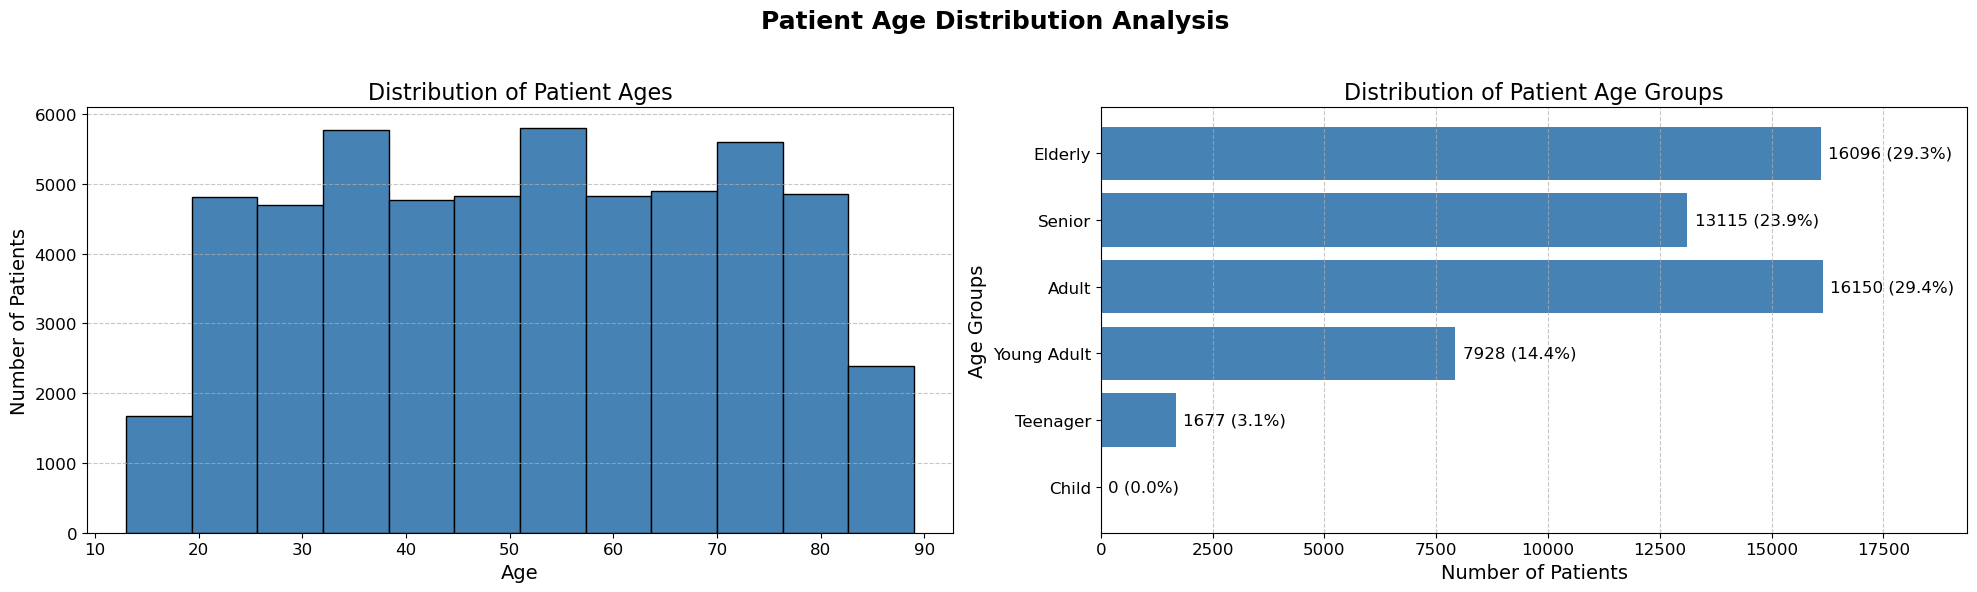

In [17]:
# 3. Questions related to data analysis

# Question 1: What is the distribution of patient ages across the dataset?

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Distribution of patients by age - Histogram
age = axes[0].hist(patients['Age'].dropna(), bins=12, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of Patient Ages', fontsize = 16)
axes[0].set_xlabel('Age', fontsize = 14)
axes[0].set_ylabel('Number of Patients', fontsize = 14)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', labelsize=12)


# Distribution of patients by age groups - Horizontal Barplot
order = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior', 'Elderly']
age_groups = patients['Age Group'].dropna().value_counts().reindex(order).fillna(0) # Reindex the bars and fill missing groups

bars = axes[1].barh(age_groups.index, age_groups.values, color='steelblue')
axes[1].set_title('Distribution of Patient Age Groups', fontsize = 16)
axes[1].set_xlabel('Number of Patients', fontsize = 14)
axes[1].set_ylabel('Age Groups', fontsize = 14)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_xlim(0, age_groups.max() * 1.2) 

# Annotate the bars
for bar in bars:
    width = bar.get_width()
    percentage = (width / age_groups.sum()) * 100       # Width is the value
    axes[1].text(width + (age_groups.max() * 0.01),    # X position with offset
             bar.get_y() + bar.get_height()/2,         # Y position (middle of bar)
             f'{int(width)} ({percentage:.1f}%)',                   
             va='center', 
             ha='left', 
             fontsize=12, 
             color='black')

# Common title
fig.suptitle('Patient Age Distribution Analysis', fontsize=18, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

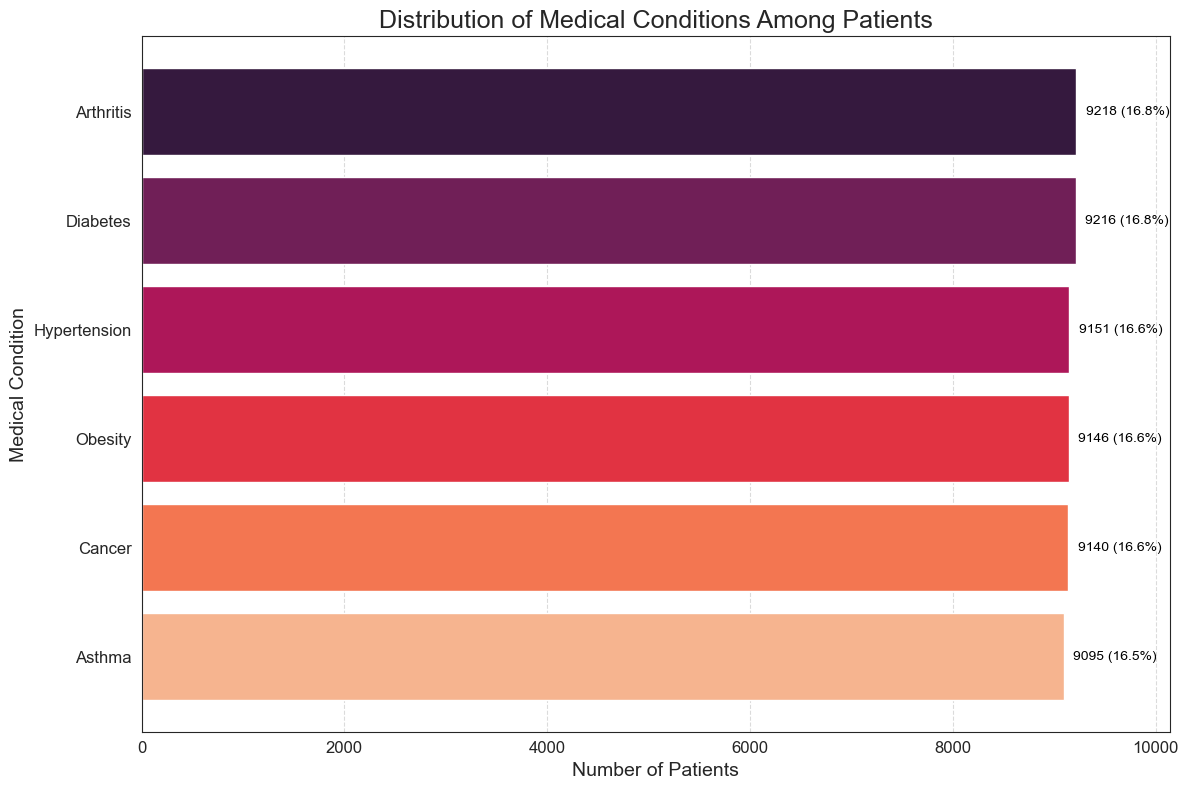

In [18]:
# Question 2: What is the most common medical condition treated in the hospital?

# Prepare the data
top_conditions = patients['Medical Condition'].value_counts().sort_values(ascending = False)
total_patients = top_conditions.sum()

# Set style
colors = sns.color_palette("rocket", len(top_conditions))
sns.set_style("white")

# Create visualization - Horizontal Barplot
plt.figure(figsize=(12,8))
bars = plt.barh(top_conditions.index, top_conditions.values, color=colors)
plt.title('Distribution of Medical Conditions Among Patients', fontsize = 18)
plt.xlabel('Number of Patients', fontsize = 14)
plt.ylabel('Medical Condition', fontsize = 14)
plt.xlim(0, top_conditions.max() * 1.1)         # Extra space for annotations
plt.gca().invert_yaxis()                        # Highest value at top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', labelsize=12)

# Annotate the bars
for bar in bars:
    width = bar.get_width()
    percentage = (width / total_patients) * 100
    plt.text(width + (top_conditions.max() * 0.01),   # X position with offset
             bar.get_y() + bar.get_height()/2,        # Y position (middle of bar)
             f'{int(width)} ({percentage:.1f}%)',     # Annotation of numbers (percentage)             
             va='center', 
             ha='left', 
             fontsize=10, 
             color='black')

plt.tight_layout()
plt.show()

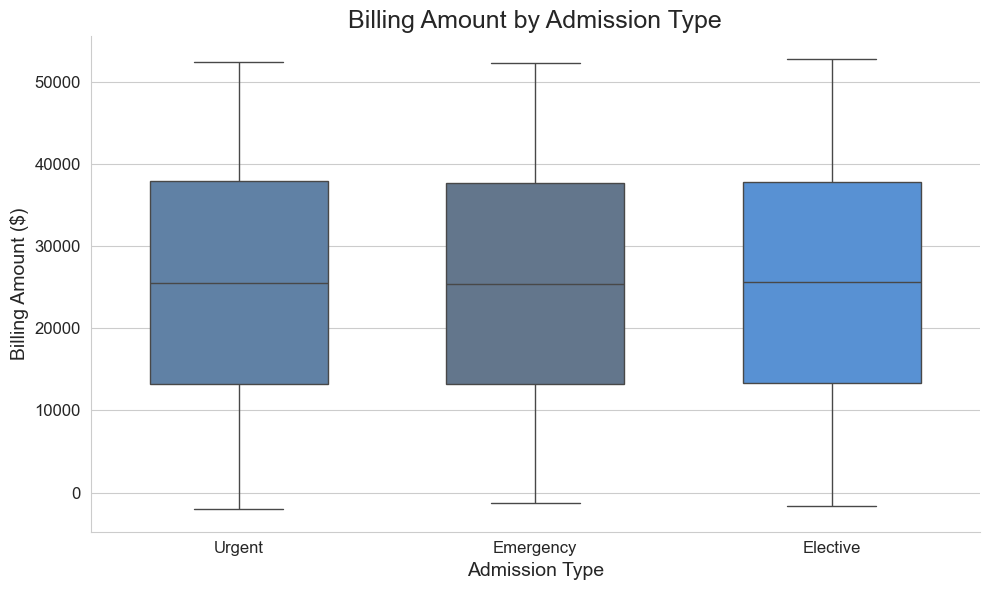

In [19]:
# Question 3: How does Billing Amount vary by Admission Type?

# Filter and Prepare Data
filtered_billing = patients[['Admission Type','Billing Amount']]
admission_types = filtered_billing['Admission Type'].unique()


# Set style
sns.set_style("whitegrid")

box_colors = ['#5580B0', '#5C7693', '#4390E8']

# Create the figure
plt.figure(figsize=(10, 6))

# Create visualization - Boxplot
sns.boxplot(
    data=filtered_billing,
    x='Admission Type', 
    y='Billing Amount',
    hue='Admission Type',
    palette=box_colors,
    width=0.6
)

plt.title('Billing Amount by Admission Type', fontsize = 18)
plt.ylabel('Billing Amount ($)', fontsize = 14)
plt.xlabel('Admission Type', fontsize = 14)
plt.tick_params(axis='both', labelsize=12)

# Clean up extra spines
sns.despine()

plt.tight_layout()
plt.show()

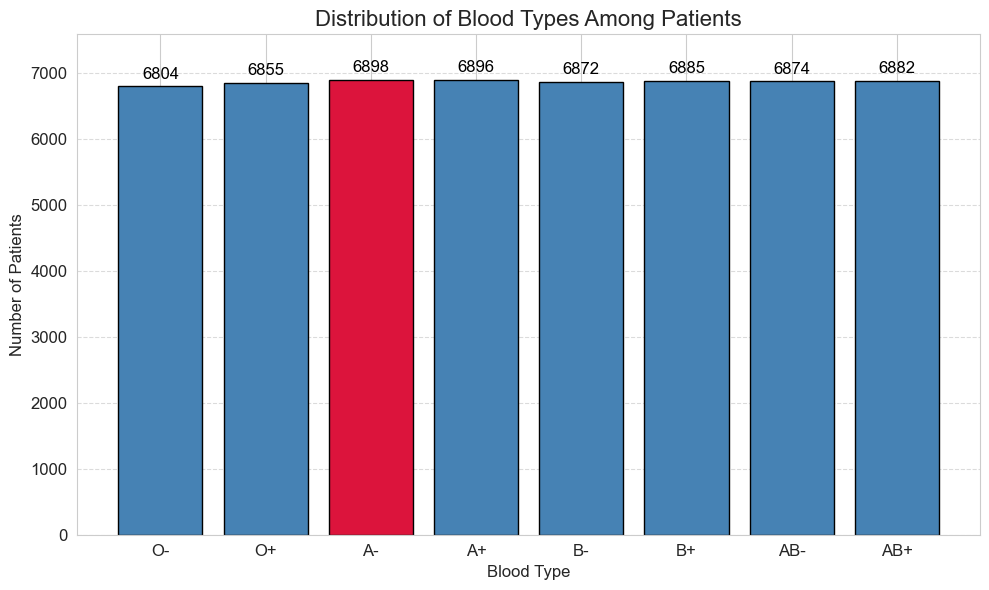

The most common bloody type is  A-  among the patients.


In [20]:
# Question 4: Which blood type is the most common among patients? 

order = ['O-', 'O+', 'A-', 'A+', 'B-', 'B+', 'AB-', 'AB+']

blood_types = patients['Blood Type'].value_counts().reindex(order).fillna(0)

# Set style - highlight the most common blood type
bar_colors = ['steelblue' if bt != blood_types.idxmax() else 'crimson' for bt in blood_types.index]

# Create visualization - Barplot
plt.figure(figsize=(10,6))
bars = plt.bar(blood_types.index, blood_types.values, color=bar_colors, edgecolor='black')
plt.title('Distribution of Blood Types Among Patients', fontsize= 16)
plt.xlabel('Blood Type', fontsize= 12)
plt.ylabel('Number of Patients', fontsize= 12)
plt.ylim(0,blood_types.max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', labelsize=12)


# Annotate the bars
for bar in bars:
    height = bar.get_height()                          # Width is the value
    plt.text(bar.get_x() + bar.get_width()/2,          # X position with offset  
             height + (blood_types.max() * 0.01),   # Y position (middle of bar)
             f'{int(height)}',                   
             va='bottom', 
             ha='center', 
             fontsize=12, 
             color='black')

plt.tight_layout()
plt.show()

print('The most common bloody type is ',blood_types.idxmax(),' among the patients.')

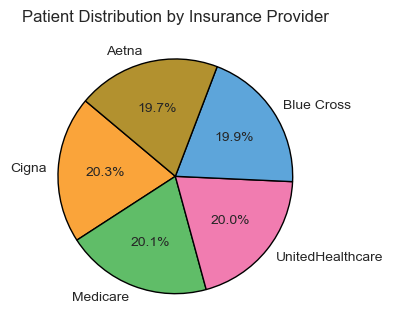

 Cigna covers the largest number of patients.


In [21]:
# Question 5: Which insurance provider covers the largest number of patients?

# Prepare the data
insurance_counts = patients['Insurance Provider'].value_counts()

# Create visualization - Pie chart
pastel_colors = ['#FAA43A', '#60BD68', '#F17CB0', '#5DA5DA', '#B2912F']

plt.figure(figsize=(4,5))
plt.pie(
    insurance_counts,
    labels=insurance_counts.index,
    autopct='%1.1f%%',                 # Show percentages
    startangle=140,                    # Rotate so largest is at top
    colors=pastel_colors,              # Nice color palette
    wedgeprops={'edgecolor': 'black'}  # Black edges between slices
)

plt.title('Patient Distribution by Insurance Provider')

plt.tight_layout()
plt.show()

print('',insurance_counts.idxmax(),'covers the largest number of patients.')

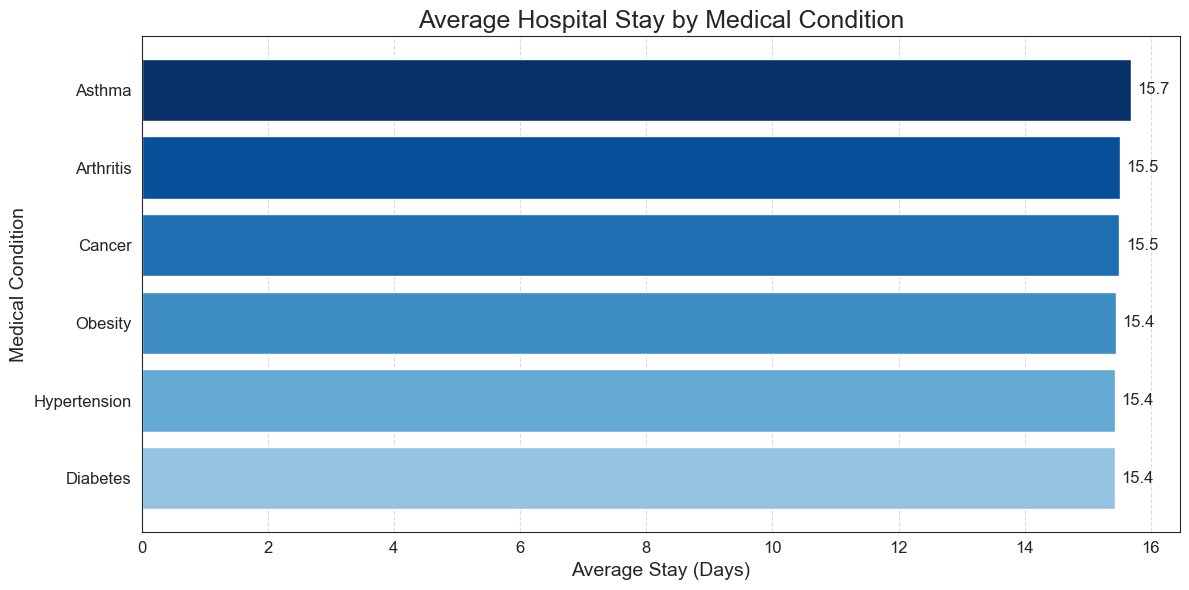

In [22]:
# Question 6: Which medical conditions are associated with the longest average hospital stays?

# Prepare the data - aggregation (mean, count)
summary = patients.groupby('Medical Condition', observed=True).agg(avg_stay=('Inpatient Days', 'mean')).sort_values('avg_stay', ascending=False)

# Set style
sns.set_style("white")
colors = cm.Blues(np.linspace(1,0.4, len(summary['avg_stay'])))

# Create visualization - horizontal Bar plot
plt.figure(figsize=(12, 6))
bars = plt.barh(summary.index, summary['avg_stay'], color= colors)

plt.title('Average Hospital Stay by Medical Condition', fontsize=18)
plt.xlabel('Average Stay (Days)', fontsize=14)
plt.ylabel('Medical Condition', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', labelsize=12)
plt.gca().invert_yaxis()             # Highest value at top

# Annotate each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1, 
        bar.get_y() + bar.get_height()/2, 
        f'{width:.1f}', 
        va='center', 
        fontsize=12
    )

plt.tight_layout()
plt.show()

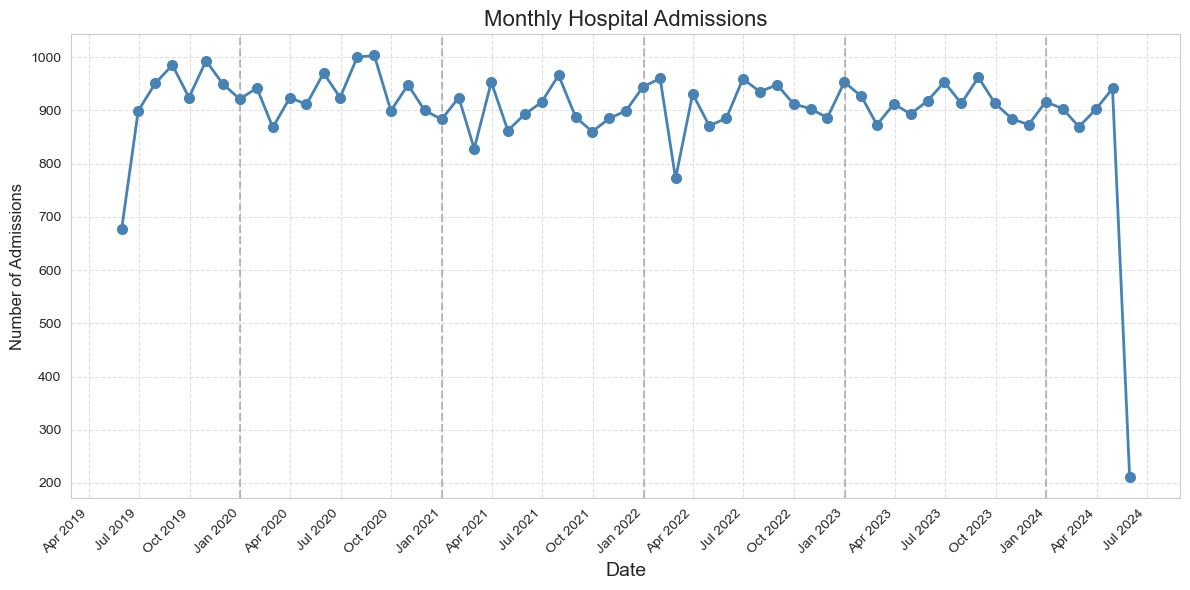

In [23]:
# Question 7: Are there seasonal trends in hospital admissions?

monthly_admissions = (
    patients
    .set_index('Date of Admission')
    .resample('ME')                 # Select monthly periods - month end
    .size()                         # Count mounths
    .reset_index(name='Admissions') # Rename column
)

# Set style
sns.set_style("whitegrid")

# Create Visualization - Line plot (Monthly Admissions)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_admissions['Date of Admission'], monthly_admissions['Admissions'],
             color='steelblue', marker='o', markersize=7, linewidth=2)
plt.title('Monthly Hospital Admissions', fontsize=16)
plt.ylabel('Number of Admissions', fontsize=12)
plt.xlabel('Date', fontsize = 14)
plt.grid(True, linestyle='--', alpha=0.6)

# Format x-axis: show every 3 months starting from January each year
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Vertical lines for year separation
years = monthly_admissions['Date of Admission'].dt.year.unique()
for year in years[1:]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

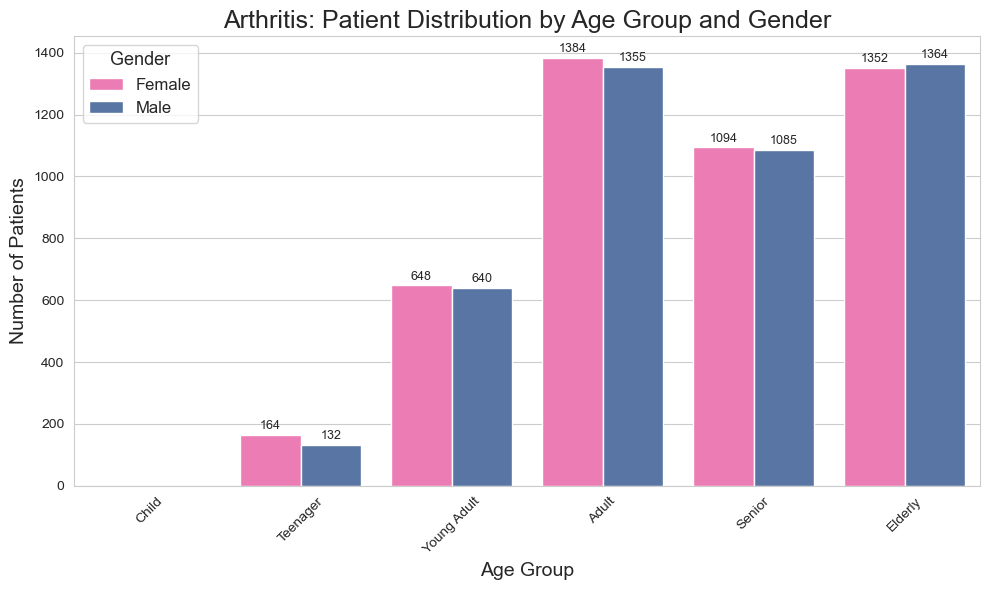

In [24]:
# Question 8: What is the distribution of Arthritis (as the most common medical condition) among patients by Age Group and Gender?

# Prepare the data
# Filter only 'Arthritis' condition
arthritis_patients = patients[patients['Medical Condition'] == 'Arthritis']

# Group by Age Group and Gender
arthritis_distribution = (
    arthritis_patients
    .groupby(['Age Group', 'Gender'])
    .size()
    .reset_index(name='Patient Count')
)

# Correct order for Age Group
age_order = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior', 'Elderly']
arthritis_distribution['Age Group'] = pd.Categorical(
    arthritis_distribution['Age Group'],
    categories=age_order,
    ordered=True
)

# Set style
sns.set_style('whitegrid')
palette = ['#FF69B4', '#4C72B0']  # Blue for Male, Pink for Female

# Create visualization - Grouped Barplot
plt.figure(figsize=(10,6))

sns.barplot(
    data=arthritis_distribution,
    x='Age Group',
    y='Patient Count',
    hue='Gender',
    palette=palette,
    dodge=True
)

# Add bar labels
for value in plt.gca().containers:
    plt.bar_label(value, fmt='%d', label_type='edge', fontsize=9, padding=2)


plt.title('Arthritis: Patient Distribution by Age Group and Gender', fontsize=18)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Gender', fontsize=12, title_fontsize=13)
plt.tight_layout()

plt.show()

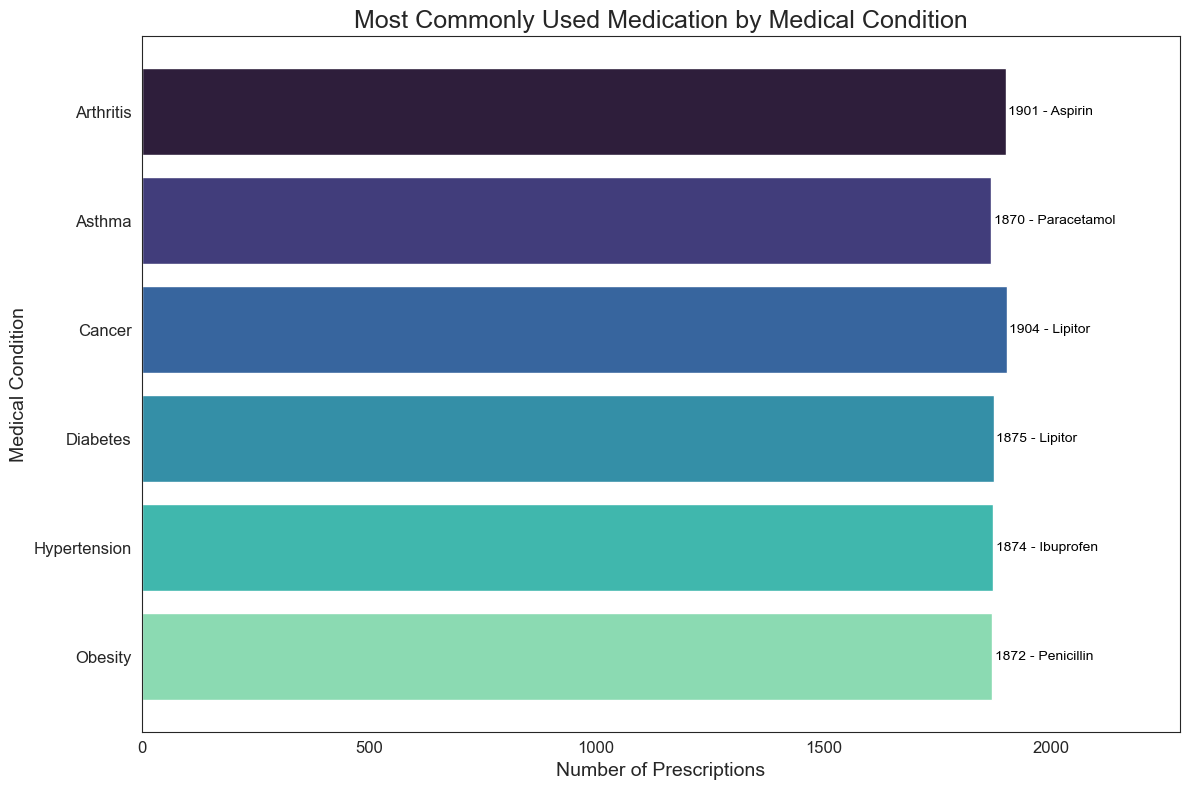

In [25]:
# Question 9: What is the most commonly used medication by medical condition?

# Group by Medical Condition and Medication
medication_by_condition = patients.groupby(['Medical Condition', 'Medication']).size().reset_index(name='Count')

# Medication with the highest count for each condition
top_medications = medication_by_condition.loc[medication_by_condition.groupby('Medical Condition')['Count'].idxmax()]

# Set Style
sns.set_style("white")

# Create visualization - Barplot
plt.figure(figsize=(12, 8))
bars = plt.barh(
    y=top_medications['Medical Condition'],
    width = top_medications['Count'],
    color=sns.color_palette("mako", len(top_medications))
)
plt.title('Most Commonly Used Medication by Medical Condition', fontsize = 18)
plt.xlabel('Number of Prescriptions',  fontsize = 14)
plt.ylabel('Medical Condition',  fontsize = 14)
plt.tick_params(axis='both', labelsize=12)
plt.xlim(0, top_medications['Count'].max() * 1.2)        # Extra space for annotations
plt.gca().invert_yaxis()                                 # Alphabetic order for medical conditions

# Annotation - count + medication name
for i, bar in enumerate(bars):
    width = bar.get_width()
    medication = top_medications['Medication'].iloc[i]
    count = top_medications['Count'].iloc[i]
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{count} - {medication}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

### Summary

- Most hospital admissions were among middle-aged and senior patients.

- Arthritis was the most common medical condition among patients.

- Emergency admissions had the greatest variation in billing amounts compared to other admission types.

- The O- blood type was the most common among the patient population.

- One insurance provider (Cigna) covered a significant majority of patients.

- Average hospitalization duration varied notably across different medical conditions.

- Among arthritis patients, gender and age group distributions showed seniors were most affected, with a slight gender skew.

- Specific medications dominated treatments for each medical condition.

Next Steps for Analysis:

- Predictive models: forecasting patient outcomes based on demographic and clinical features

- Clustering: patient profiling, pattern recognition for hospitalization

- Perform deeper condition-based studies beyond arthritis, including co-occurrence of multiple conditions.

- Design an interactive dashboard to visualize trends for healthcare providers and policy decision-makers.